In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno #Libreria visualizar valores faltantes
from sklearn.model_selection import train_test_split
df = pd.read_csv("./Titanic_train.csv")
df_train = pd.read_csv("./Titanic_test.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df_train.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
df.shape

(891, 12)

In [4]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Posibles variables categoricas (Object): Name, Sex, Ticket, Cabin, Embarked
Posibles variables categoricas (Descripcion): Survived, PClass (ordinal)

Posible sin importancia: Name, Passenger Id

Valores faltantes: Age porque tiene count 714
Psoibles outliers: Age tiene de minimo 0, Fare (Valor ticket) tiene minimo 0

## Valores Faltantes

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Hay ausencia de datos en: Age (86) y Cabin (327)
Para saber si imputar 
*Es MCAR?
*Es < 5%

<Axes: >

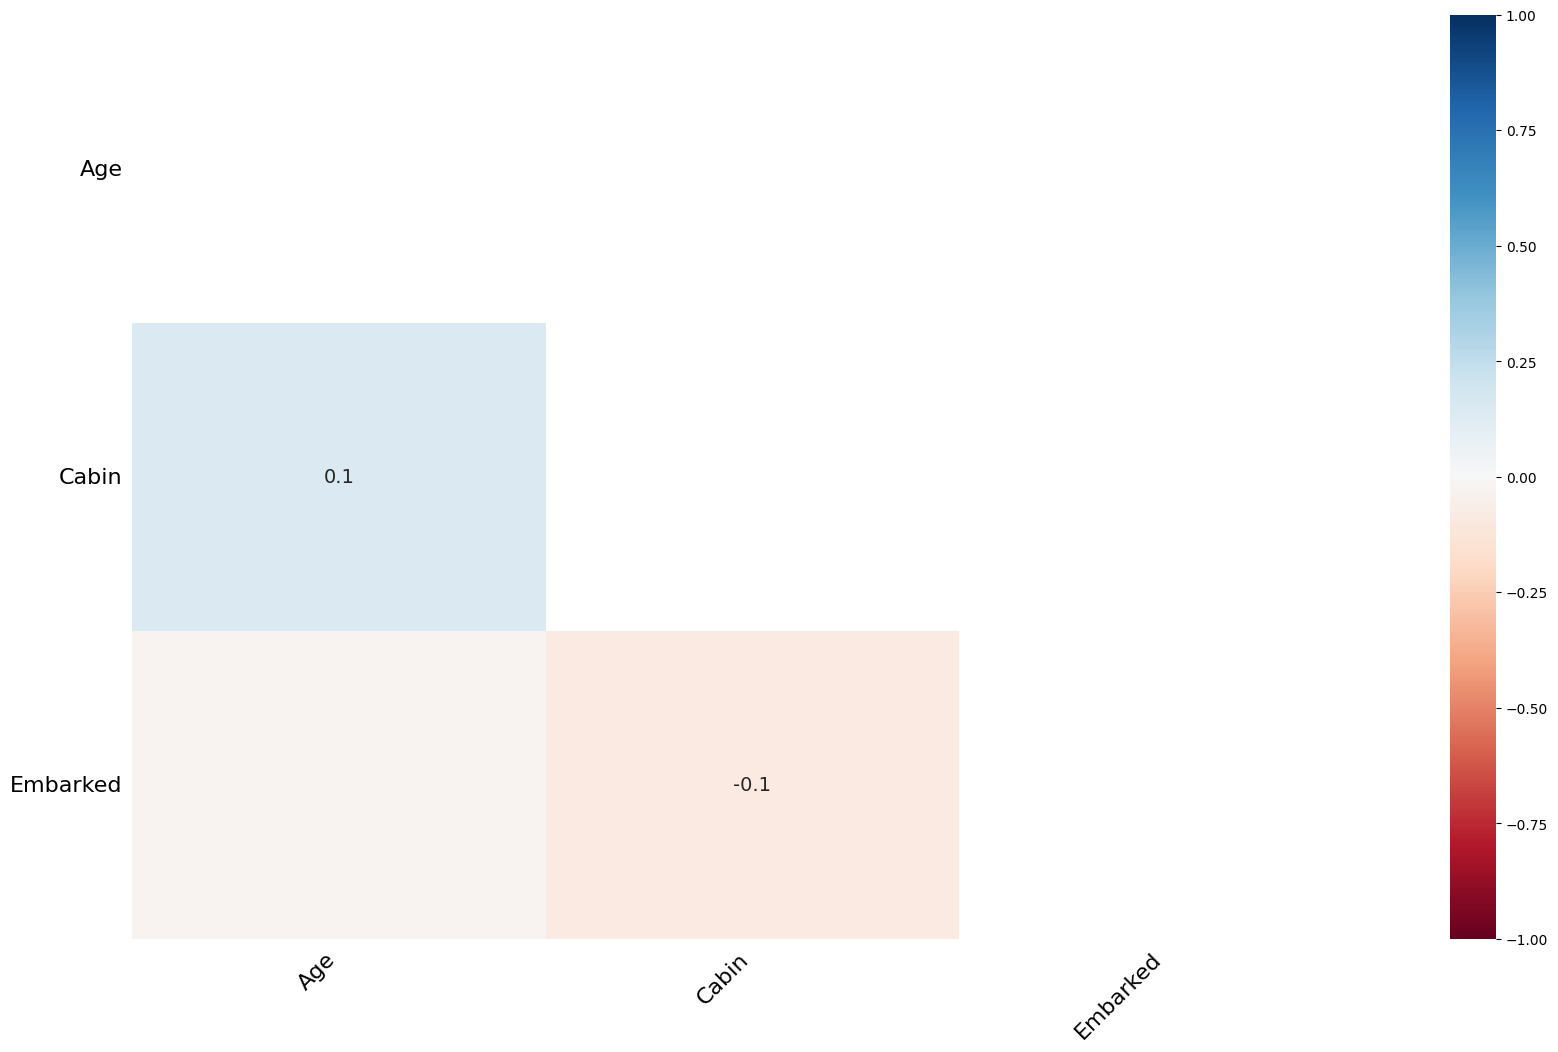

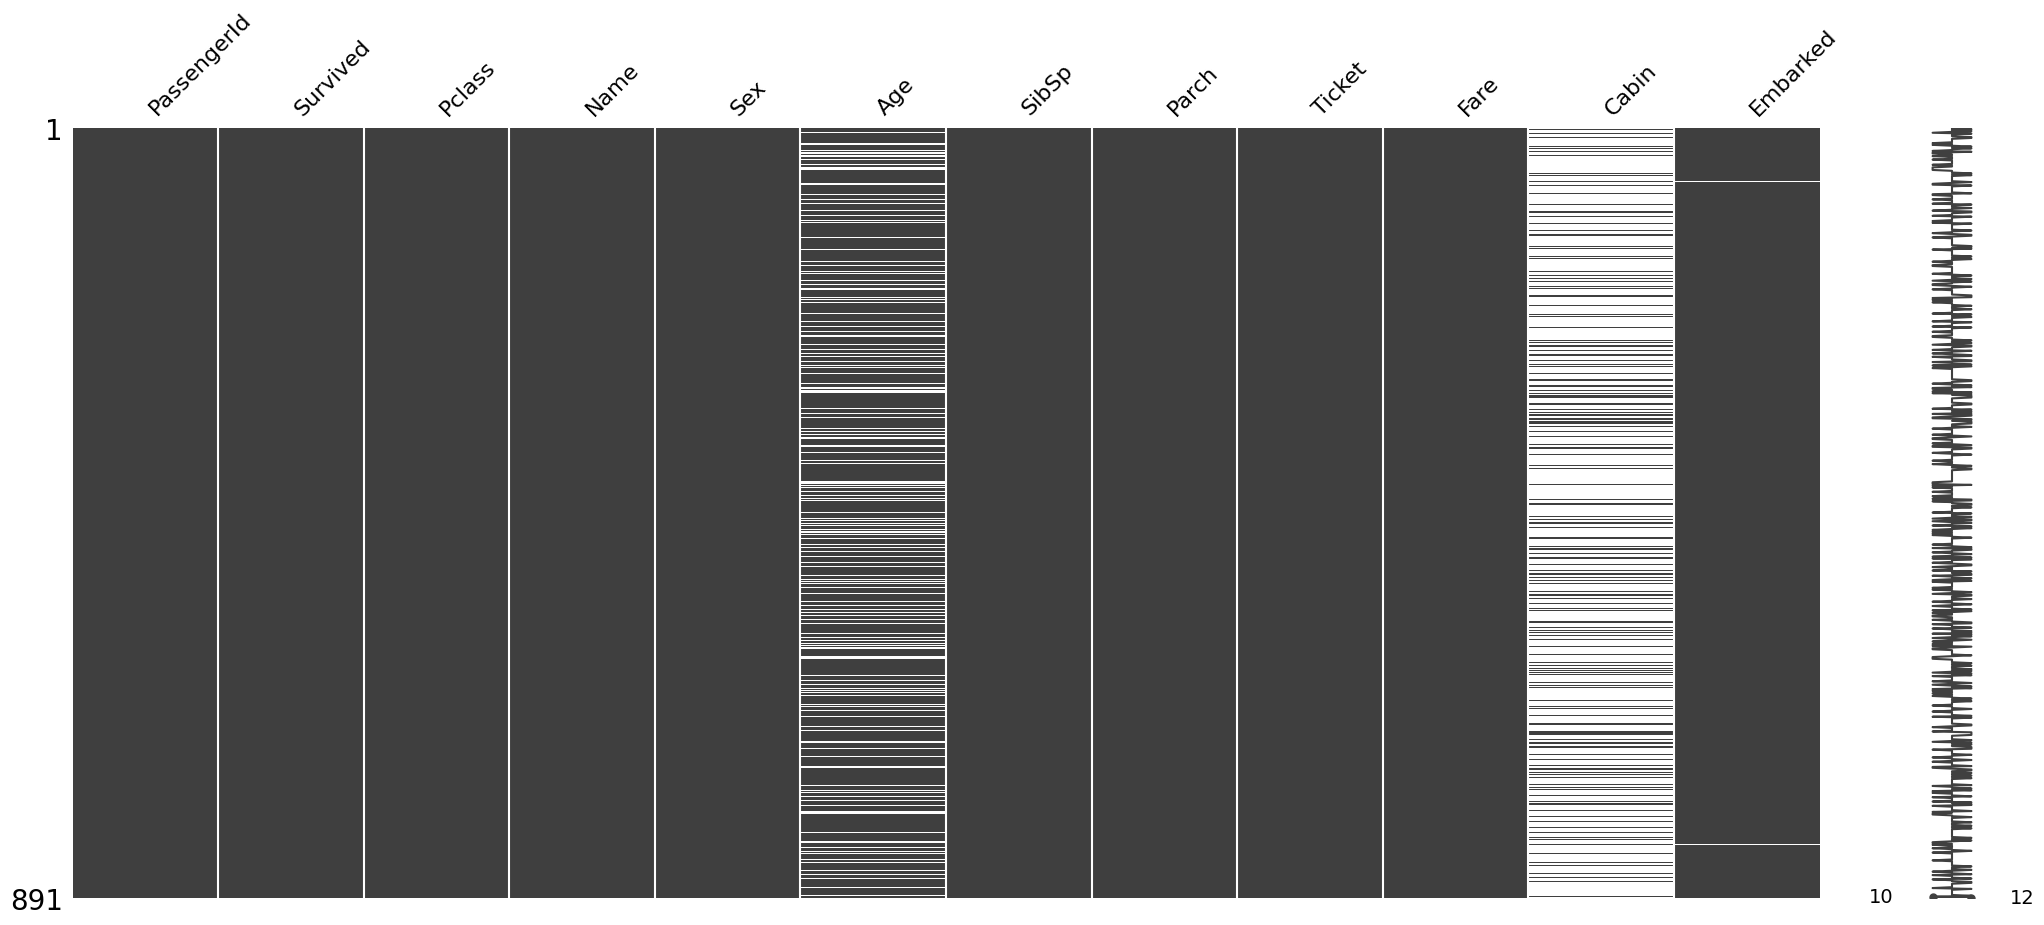

In [6]:
# Es MCAR?
msno.heatmap(df)
msno.matrix(df)

Heatmap Nulidad

Correlaciones muy bajas entre Cabin vs Age , y Cabin vs Embarked. Hay MCAR

Matriz Nulidad

* Age : Varios valores faltantes
* Cabin : Muchisimos valores faltantes (Casi toda la columna blanca)

In [7]:
# % faltantes < 5%?
porcentaje = df.isnull().sum()/df.shape[0]
porcentaje

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

Cabin tiene el 0.77 de valores faltantes, debería ser <0.5, Hay que eliminarla

In [8]:
df = df.drop(columns=["Cabin"])

In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


Ahora se debe decidir cómo imputar los valores de "Age" y "Embarked"
* "Age" es continua -> Puede ser imputación por media si tiene distr normal, si es skewed es imputación por mediana
* "Embarked" es categorica -> Debe ser imputación por moda


<Axes: xlabel='Age', ylabel='Count'>

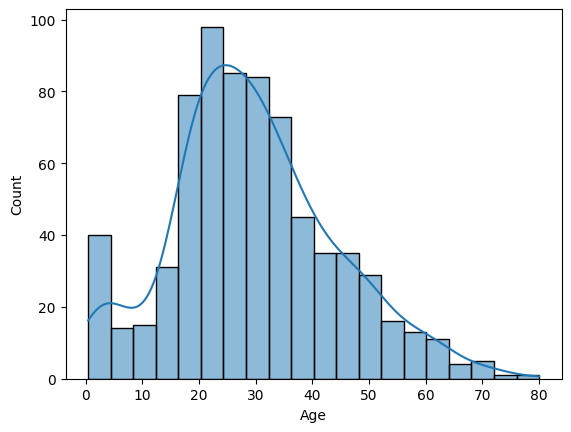

In [10]:
#Mirar distribución de age
sns.histplot(df["Age"],kde = True)


La distribución de la variable Age está sesgada a la derecha, se va a hacer imputación por mediana. En resumen

Imputacion valores faltantes
* Age -> Imputación por mediana
* Embarked -> Imputación por moda

## Unicidad
Ahora, se va a revisar la unicidad, es decir si hay registros duplicados

In [11]:
print(df.duplicated(keep=False).sum())

#Ver id duplicados
print(df["PassengerId"].duplicated().sum())

#Cuantas veces aparece cada ID
df["PassengerId"].value_counts()[df["PassengerId"].value_counts()>1]

0
0


Series([], Name: count, dtype: int64)

In [12]:
#Ver name duplicados
print(df["Name"].duplicated().sum())

#Cuantas veces aparece cada name
df["Name"].value_counts()[df["Name"].value_counts()>1]

0


Series([], Name: count, dtype: int64)

Se va a eliminar "idpassenger" ya que cada fila tiene un id unico y no tiene relación con variable objetivo. También "Name" , ya que cada nombre es diferente

In [13]:
df = df.drop(columns=["PassengerId", "Name"])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,female,35.0,1,0,113803,53.1000,S
4,0,3,male,35.0,0,0,373450,8.0500,S


## Consistencia
Mirar si en una categoria hay nombres similares par alas variables tipo "object", posibles categoricas

In [14]:
print(df["Sex"].value_counts())
print(df["Ticket"].value_counts())
print(df["Embarked"].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64
Ticket
347082              7
1601                7
CA. 2343            7
3101295             6
CA 2144             6
                   ..
PC 17590            1
17463               1
330877              1
373450              1
STON/O2. 3101282    1
Name: count, Length: 681, dtype: int64
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


No se encontro que alguna categoría estuviera repetida para las variables categoricas analizadas que son de tipo object. Sin embargo, se evidencia que la variable "ticket" tiene 681 valores distintos, lo que significa que tiene una alta cardinalidad y los encoders harían muchas columnas de esto, lo cual es un problema. Además, es un identificador administrativo, as+i que tiene poco valor predictivo, se decide eliminar

In [15]:
df = df.drop(columns = ["Ticket"])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## Validez


In [16]:
# Verificar rango survived
df["Survived"].unique()

array([0, 1])

## Outliers

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')


<Axes: >

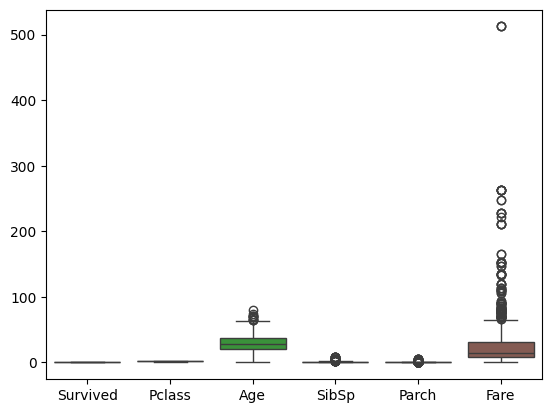

In [17]:
numeric_cols = df.select_dtypes(include=["number"]).columns
print(numeric_cols)

sns.boxplot(data=df.select_dtypes(include=["number"]))


<Axes: >

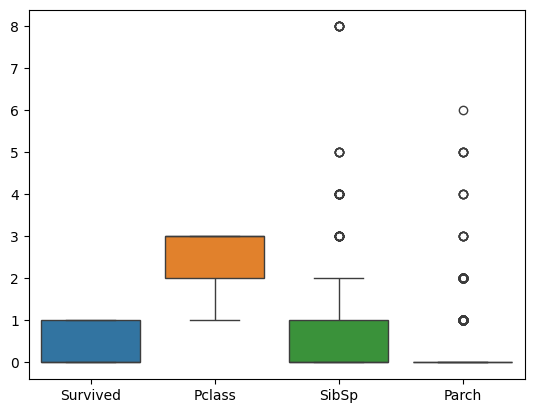

In [18]:
sns.boxplot(data = df[["Survived", "Pclass", "SibSp","Parch"]])

<Axes: >

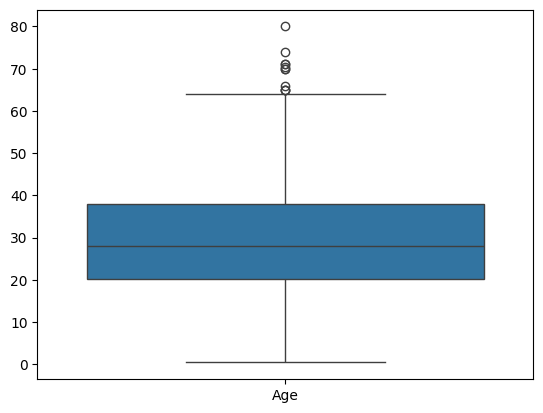

In [19]:
sns.boxplot(data = df[["Age"]])

<Axes: >

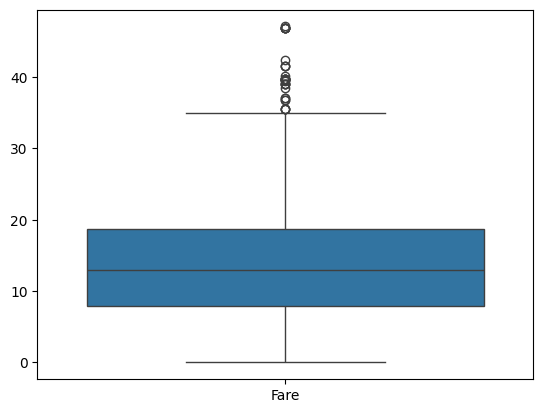

In [99]:
sns.boxplot(data = df[["Fare"]])

En los boxplots nos podemos dar cuenta que fare presenta una gran cantidad de valores atipicos, age tambien presenta algunos valores atipicos. Y parch y Sisbp también unos cuantos

In [76]:
from sklearn.impute import SimpleImputer


def replace_outliers_median(df,col):
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1-1.5*IQR
    upper= Q3+1.5*IQR
    mask = (df[col]<lower) | (df[col] > upper)
    df.loc[mask, col] = np.nan

    # imputar con mediana
    imputer = SimpleImputer(strategy="median")
    df[col] = imputer.fit_transform(df[[col]])
    return (df)


df=replace_outliers_median(df,"Fare")


<Axes: >

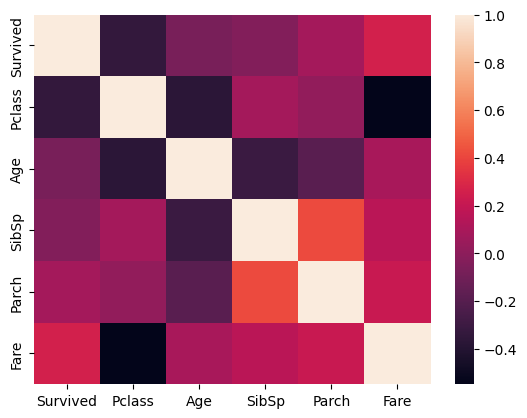

In [ ]:
# Matriz de correlaciones
sns.heatmap(df.corr(numeric_only=True))

<Axes: xlabel='Pclass', ylabel='Fare'>

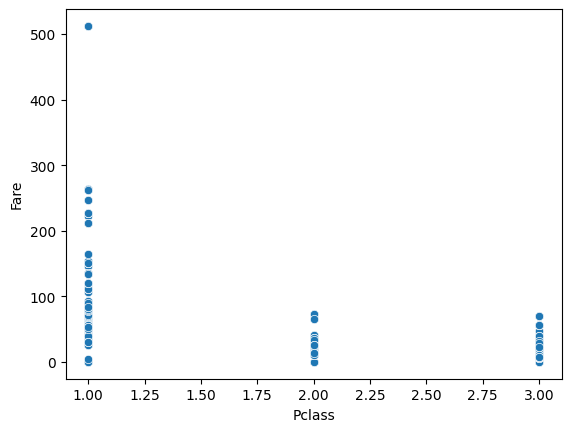

In [ ]:
sns.scatterplot(data = df,  x="Pclass",y="Fare")

<Axes: xlabel='SibSp', ylabel='Parch'>

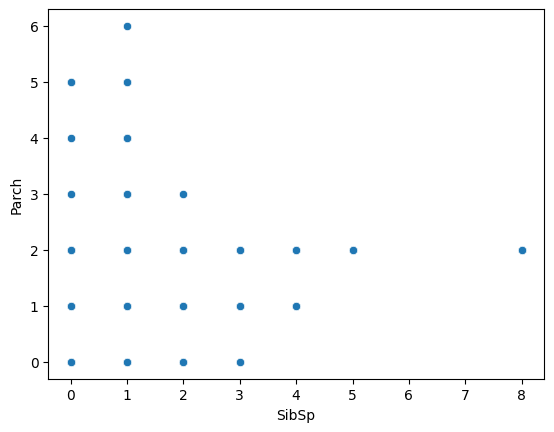

In [ ]:
sns.scatterplot(data = df,  x="SibSp",y="Parch")

<Axes: xlabel='Pclass', ylabel='count'>

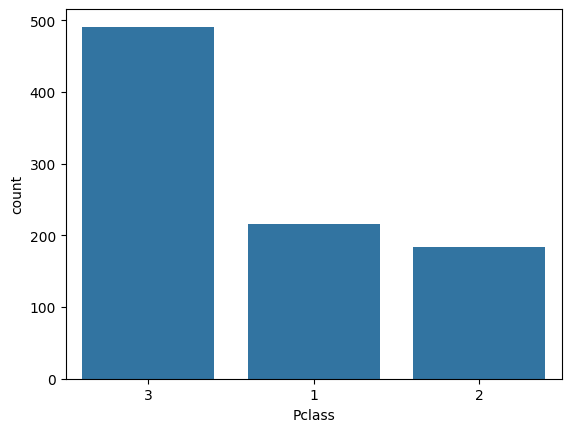

In [ ]:
sns.countplot(data = df, x="Pclass", order = df["Pclass"].value_counts().index)

# Feature Engineering

Crear variables para ayudar al modelo

## Pipeline

In [77]:
x = df.drop("Survived", axis = 1)
y = df["Survived"]

In [78]:
#Train/Test split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2,random_state=42)

In [79]:
numeric_cols = x_train.select_dtypes(include=["number"]).columns
categorical_cols = x_train.select_dtypes(exclude=["number"]).columns
ordinal_cols = ["Pclass"]
print(numeric_cols,categorical_cols,ordinal_cols)
x.head()

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object') Index(['Sex', 'Embarked'], dtype='object') ['Pclass']


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.250,S
1,1,female,38.0,1,0,13.000,C
2,3,female,26.0,0,0,7.925,S
3,1,female,35.0,1,0,13.000,S
4,3,male,35.0,0,0,8.050,S


In [80]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder


numeric_transformer = Pipeline([
    ("Imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()) #O hay MinMaxScaler()
])

categorical_transformer = Pipeline([
    ("Imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first"))
])

ordinal_transformer = Pipeline([
    ("Imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinalencoder", OrdinalEncoder())
])

In [81]:
from sklearn.compose import ColumnTransformer


preprocessor = ColumnTransformer(
    transformers=[
    ("num", numeric_transformer,numeric_cols),
    ("cat",categorical_transformer,categorical_cols),
    ("ord",ordinal_transformer,ordinal_cols)],
    remainder = "drop"
)

In [82]:
from sklearn.linear_model import LogisticRegression


pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression())
])

In [87]:
#Param Grid
param_grid = [
    #"model" : [Ridge(), Lasso()],  no se puede porque es modelo de clasificacion
    #"model__alpha" : [0.001,0.01,0.0001,1,10],

    # Combinaciones válidas con L2
    {
        'model__penalty': ['l2'],
        'model__solver': ['newton-cg', 'lbfgs', 'liblinear'],
        'model__C': [0.1, 0.2, 0.5, 0.8, 1]
    },
    # Combinaciones válidas con L1
    {
        'model__penalty': ['l1'],
        'model__solver': ['liblinear'],
        'model__C': [0.1, 0.2, 0.5, 0.8, 1]
    }

]

In [88]:
# Grid Search
from sklearn.model_selection import GridSearchCV, KFold


grid = GridSearchCV(
    pipeline,
    param_grid,
    cv = KFold(n_splits=5,shuffle = True, random_state=42),
    scoring = "roc_auc"
)

In [89]:
#Entrenar
grid.fit(x_train,y_train)

c:\Users\maria\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\maria\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\maria\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__C': [0.1, 0.2, ...], 'model__penalty': ['l2'], 'model__solver': ['newton-cg', 'lbfgs', ...]}, {'model__C': [0.1, 0.2, ...], 'model__penalty': ['l1'], 'model__solver': ['liblinear']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intCont

In [90]:
params = grid.best_params_
best_model = grid.best_estimator_ 

print(params)
print(best_model)

{'model__C': 0.2, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                        

In [92]:
from sklearn.metrics import classification_report
y_pred = best_model.predict(x_test)

#Metricas
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [93]:
from sklearn.metrics import confusion_matrix


confusion_matrix(y_test,y_pred)

array([[90, 15],
       [19, 55]])

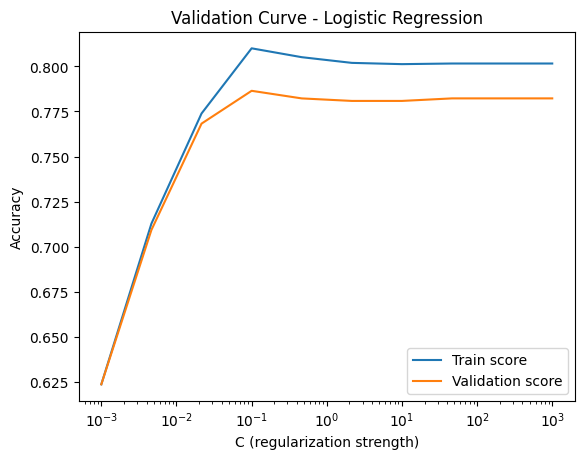

In [94]:
#Curvas de valiudación
from sklearn.model_selection import validation_curve

param_range= np.logspace(-3,3,10)
train_scores, val_scores = validation_curve(
    pipeline,
    x_train,
    y_train,
    param_name="model__C",
    param_range= np.logspace(-3,3,10),
    cv=5,
    scoring="accuracy"
)

#Promedio de los resultados
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

#Graficar la curva
import matplotlib.pyplot as plt

plt.plot(param_range, train_mean, label="Train score")
plt.plot(param_range, val_mean, label="Validation score")

plt.xscale("log")
plt.xlabel("C (regularization strength)")
plt.ylabel("Accuracy")
plt.title("Validation Curve - Logistic Regression")
plt.legend()

plt.show()

In [95]:
#Bootstrapping
from sklearn.utils import resample
from sklearn.metrics import accuracy_score
import numpy as np

scores = []

for i in range(500):

    # remuestreo con reemplazo
    X_sample, y_sample = resample(x_test, y_test)

    # predicción
    y_pred = best_model.predict(X_sample)

    # calcular métrica
    acc = accuracy_score(y_sample, y_pred)

    scores.append(acc)

In [96]:
print(np.percentile(scores,[2.5,97.5]))

[0.75977654 0.8603352 ]


In [97]:
df_test = pd.read_csv("./Titanic_test.csv")
x_test = df_test
predictions = best_model.predict(x_test)


In [98]:
submission = pd.DataFrame({
    "PassengerId": df_test["PassengerId"],
    "Survived": predictions
})

submission.to_csv("submission.csv", index=False)